# Practical 01: Content Analysis (Topic Modelling with LDA)

This notebook follows the SMA Practical Exam 2026 structure and applies topic modelling on news text.


## Common Practical Workflow
1. Import libraries  
2. Load CSV (pandas)  
3. Inspect (`head`, `info`, `isnull`)  
4. Clean (nulls, duplicates, text cleanup)  
5. Apply method  
6. Visualize (matplotlib/seaborn)  
7. Interpret findings


## Step 1: Import Libraries
Theory: We use NLP tools for text cleaning/tokenization and `gensim` for LDA topic modelling.


In [8]:
%pip install gensim

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel


## Step 2 and 3: Load and Inspect Dataset
Theory: Always inspect shape, columns, data types, and missing values before analysis.


In [9]:
df = pd.read_csv('news_data.csv')
print(df.head())
print('Shape:', df.shape)
print('Info:')
df.info()
print('Null values:')
print(df.isnull().sum())


                                               title  \
0  Russia, Ukraine trade accusations of Orthodox ...   
1  Bitcoin dips to $70.6K, oil rises after US ann...   
2  Russia Blasts Through Ukraine Cease-Fire, as T...   
3  India ramps up Russian oil imports as sanction...   
4  Hungarian PM Viktor Orban ejected after 16 yea...   

                                         description  \
0  Russia and Ukraine traded accusations over cea...   
1  Bitcoin retraced below $71,000 after failed pe...   
2  Russia Blasts Through Ukraine Cease-Fire, as T...   
3  Indian refiners are boosting Russian crude oil...   
4  Hungarian voters ousted long-serving Prime Min...   

                                             content              source  \
0  Moscow: Russia and Ukraine accused each other ...  The Times of India   
1  Bitcoin fell as low as $70,623 on Sunday after...       Cointelegraph   
2  The Fine Print: The following comments are own...        Slashdot.org   
3  Indian refiners hav

## Step 4: Clean Text
Theory: We combine title and description, lower-case text, remove punctuation and stopwords, then tokenize.


In [10]:
df = df.drop_duplicates().copy()
df['combined_text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 3]
    return tokens

df['tokens'] = df['combined_text'].apply(clean_text)
print(df[['combined_text', 'tokens']].head(3))


                                       combined_text  \
0  Russia, Ukraine trade accusations of Orthodox ...   
1  Bitcoin dips to $70.6K, oil rises after US ann...   
2  Russia Blasts Through Ukraine Cease-Fire, as T...   

                                              tokens  
0  [russia, ukraine, trade, accusations, orthodox...  
1  [bitcoin, dips, rises, announces, hormuz, bloc...  
2  [russia, blasts, ukraine, cease, fire, trump, ...  


## Step 5: Create Corpus and Apply LDA
Theory: LDA discovers hidden themes by assigning words to latent topics.


In [11]:
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

NUM_TOPICS = 4
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto'
)

for i in range(NUM_TOPICS):
    words_only = [w for w, _ in lda_model.show_topic(i, topn=8)]
    print(f'Topic {i+1}: {", ".join(words_only)}')


Topic 1: iran, ukraine, orban, israel, data, telenor, lawsuit, hungary
Topic 2: ukraine, easter, russia, world, iran, ceasefire, people, russian
Topic 3: iran, blockade, hormuz, ceasefire, strait, israel, talks, trump
Topic 4: myanmar, president, years, aung, hlaing, viktor, junta, chief


## Step 6: Visualize Topics
Theory: Bar charts make top words per topic easier to interpret.


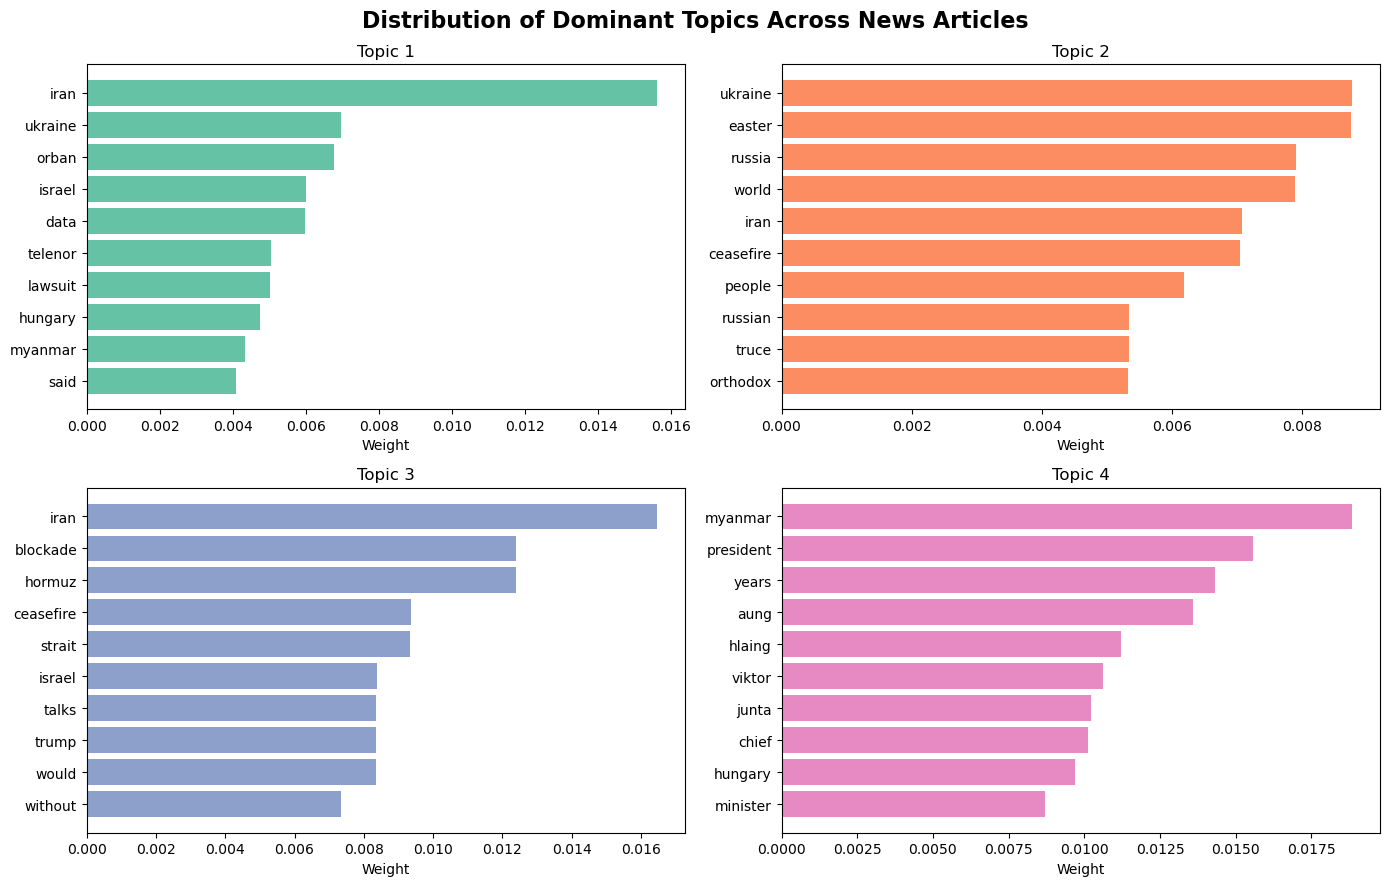

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    top_words = lda_model.show_topic(i, topn=10)
    words = [w for w, _ in top_words]
    weights = [wt for _, wt in top_words]

    axes[i].barh(words[::-1], weights[::-1], color=plt.cm.Set2(i))
    axes[i].set_title(f'Topic {i+1}')
    axes[i].set_xlabel('Weight')

plt.suptitle('Distribution of Dominant Topics Across News Articles', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


## Step 7: Interpretation
- Topics represent recurring themes in the article collection.  
- Top words in each topic should be manually labeled (for example: conflict, diplomacy, economy, policy).  
- This supports content understanding at scale.
